# Study of the expectations hypothesis

In [1]:
# %pip install statsmodels

In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.interpolate import CubicSpline

plt.style.use('seaborn-v0_8-whitegrid')
example_root = Path(os.path.abspath(""))

## Data loading

In [3]:
eurirs_df = pd.read_csv(example_root / "data" / f"EURIRS_history_2000-01-01_to_2025-12-31.csv")
eurbmk_df = pd.read_csv(example_root / "data" / f"0#EUBMK=_history_2000-01-01_to_2025-12-31.csv")

In [4]:
buckets = dict([(f"{i}M", i / 12.) for i in range(1, 19)] + [(f"{i}Y", i) for i in range(1, 51)])

In [5]:
# Rename the columns for EURIRS Curve
eurirs_map = {}

for col in eurirs_df.columns:
  if col == "Date":
    continue
  
  col_mat = col.split("=")[0][-3:]
  
  try:
    col_ttm  = int(col_mat[:2])
    col_mat = col_mat
  except Exception as e:
    col_mat = col_mat[1:]
  
  eurirs_map[col] = col_mat
  
eurirs_df.rename(columns=eurirs_map, inplace=True)

In [6]:
# Rename the columns for 0#EUBMK= Curve
eurbmk_map = {}

for col in eurbmk_df.columns:
  if col == "Date":
    continue
  
  col_mat = col.split("=")[0][-4:-1]
  
  try:
    col_ttm  = int(col_mat[:2])
    col_mat = col_mat
  except Exception as e:
    col_mat = col_mat[1:]
  
  eurbmk_map[col] = col_mat
  
eurbmk_df.rename(columns=eurbmk_map, inplace=True)

In [7]:
data_color  = "royalblue"
model_color = "indianred"

## Forecasting 1M spot rate

The yield curve is assumed to represent continuously compounding rates. The forward rate $f$ from time $t$ to $T$ is then given by

$$
f(t, T) = \frac{r(T)T - r(t)t}{T - t} ,
$$

where $r$ is the spot rate.

Fama (1984a) found that the expectations hypothesis seems to hold to a statistically significant level for shorter term rate (max 6 months). To study this the regression by Fama can be used to evaluate the predictive power of 1M forward in 2M when forecasting the future 1M spot rate. The regression is of form

$$
r(T) - r(t) = \alpha + \beta (f(t, T) - r(t)) + \epsilon .
$$

Since the EURIRS curve starts at 1Y, this study only considers the European Government Benchmark Yield Curve. Additionally, as the closest point to 1M spot is the 3M spot, the 2M spot must be interpolated. Cubic splines are used to accomplish this interpolation.

In [8]:
# Columns for 9M and 25Y are poorly filled so drop them
tmp_eurbmk_df = eurbmk_df.drop(columns=["25Y", "9M"])
tmp_eurbmk_df = tmp_eurbmk_df.dropna()

value_cols    = [col for col in tmp_eurbmk_df.columns if col != "Date"]
eurbmk_curves = []

for i, row in tmp_eurbmk_df.iterrows():
  rowx = row[value_cols]
  vals = rowx.values
  indx = rowx.index
  indx = [buckets[ind] for ind in indx]
  
  ind_val_tups = [(indx[i], vals[i]) for i in range(len(indx))]
  ind_val_tups.sort(key=lambda tup: tup[0])
  
  indx = [tup[0] for tup in ind_val_tups]
  vals = [tup[1] for tup in ind_val_tups]
  
  curve = CubicSpline(indx, vals)
  eurbmk_curves.append((row["Date"], curve))

The curves extend from 2003 until the end of the considered period in 2025 (the very last day 2025-12-31 is missing the 1Y spot and is thus excluded)

In [9]:
print(f"First curve: {eurbmk_curves[0][0]}")
print(f"Last curve: {eurbmk_curves[-1][0]}")

First curve: 2003-06-10
Last curve: 2025-12-30


The short-term rate DataFrame can be formed as

In [10]:
eurbmk_short_term_df = pd.DataFrame.from_dict({"Date": [tup[0] for tup in eurbmk_curves],
                                               "1M": [tup[1](1. / 12.) for tup in eurbmk_curves],
                                               "2M": [tup[1](2. / 12.) for tup in eurbmk_curves],
                                               "3M": [tup[1](3. / 12.) for tup in eurbmk_curves]})
eurbmk_short_term_df["F1M2M"] = [(row["2M"] * 2. / 12. - row["1M"] * 1. / 12.) / (1. / 12.) for _, row in eurbmk_short_term_df.iterrows()]
eurbmk_short_term_df.index    = pd.DatetimeIndex(eurbmk_short_term_df["Date"])

Building towards the regression the differences in rates are

In [11]:
eurbmk_short_term_df["D1M"]       = eurbmk_short_term_df["1M"].diff()                                     # The one day difference in the 1M spot rate
eurbmk_short_term_df["D1M_1M"]    = eurbmk_short_term_df["D1M"].rolling(f'30D').sum().astype(np.float64)  # The 30 day (total days) difference in the 1M spot rate
eurbmk_short_term_df["DF2M1M"]    = [row["F1M2M"] - row["1M"] for _, row in eurbmk_short_term_df.iterrows()]
eurbmk_short_term_df["D1M_F2M1M"] = eurbmk_short_term_df["DF2M1M"].shift(periods=30, freq='D').astype(np.float64)

### Full dataset

In [12]:
tmp_eurbmk_short_term_df = eurbmk_short_term_df.dropna()
results = smf.ols("D1M_1M ~ D1M_F2M1M", data=tmp_eurbmk_short_term_df).fit()

In [13]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 D1M_1M   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     2592.
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:39:37   Log-Likelihood:                 1057.6
No. Observations:                3185   AIC:                            -2111.
Df Residuals:                    3183   BIC:                            -2099.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0158      0.003     -5.115      0.0

In [14]:
results.params

Intercept   -0.01579
D1M_F2M1M    0.80766
dtype: float64

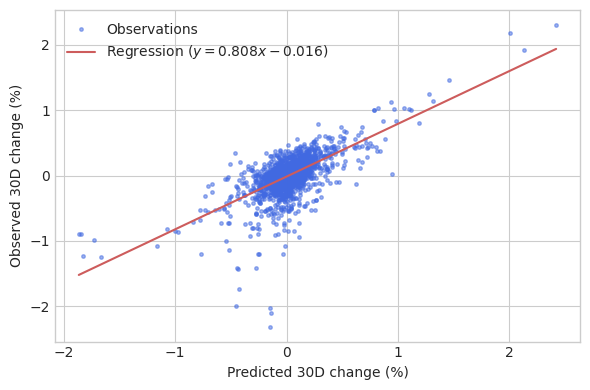

In [15]:
fig = plt.figure(figsize=(6, 4))
nn = np.linspace(min(tmp_eurbmk_short_term_df["D1M_F2M1M"]), max(tmp_eurbmk_short_term_df["D1M_F2M1M"]), 100)

plt.plot(tmp_eurbmk_short_term_df["D1M_F2M1M"], tmp_eurbmk_short_term_df["D1M_1M"], linestyle="None", marker=".", markersize=5, alpha=0.5, color=data_color, label="Observations")
plt.plot(nn, results.params["Intercept"] + results.params["D1M_F2M1M"] * nn, color=model_color, label=f"Regression ($y = {results.params["D1M_F2M1M"]:.3f} x {'+' if results.params["Intercept"] > 0 else ''} {results.params["Intercept"]:.3f}$)")

plt.legend()
plt.xlabel("Predicted 30D change (%)")
plt.ylabel("Observed 30D change (%)")

fig.tight_layout()
fig.savefig(example_root / "figures" / "EURBMK_regression_1M_2003_2025.png")
fig.savefig(example_root / "figures" / "EURBMK_regression_1M_2003_2025.pdf")

plt.show()

### Dataset from 2020-2025

In [16]:
tmp_eurbmk_short_term_df = eurbmk_short_term_df.dropna().query("Date > '2020-01-01'")
results = smf.ols("D1M_1M ~ D1M_F2M1M", data=tmp_eurbmk_short_term_df).fit()

In [17]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 D1M_1M   R-squared:                       0.496
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     880.4
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          3.17e-135
Time:                        18:39:37   Log-Likelihood:                 84.077
No. Observations:                 896   AIC:                            -164.2
Df Residuals:                     894   BIC:                            -154.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0013      0.007     -0.177      0.8

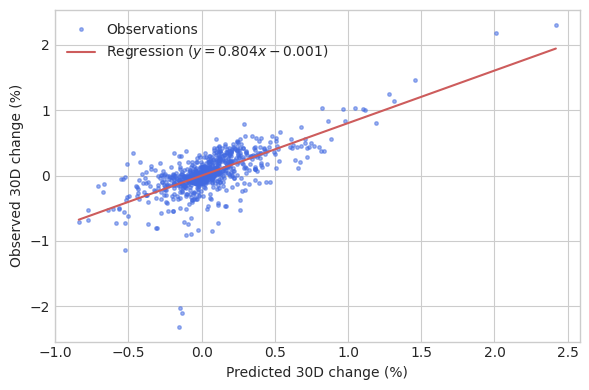

In [18]:
fig = plt.figure(figsize=(6, 4))
nn = np.linspace(min(tmp_eurbmk_short_term_df["D1M_F2M1M"]), max(tmp_eurbmk_short_term_df["D1M_F2M1M"]), 100)

plt.plot(tmp_eurbmk_short_term_df["D1M_F2M1M"], tmp_eurbmk_short_term_df["D1M_1M"], linestyle="None", marker=".", markersize=5, alpha=0.5, color=data_color, label="Observations")
plt.plot(nn, results.params["Intercept"] + results.params["D1M_F2M1M"] * nn, color=model_color, label=f"Regression ($y = {results.params["D1M_F2M1M"]:.3f} x {'+' if results.params["Intercept"] > 0 else ''} {results.params["Intercept"]:.3f}$)")

plt.legend()
plt.xlabel("Predicted 30D change (%)")
plt.ylabel("Observed 30D change (%)")

fig.tight_layout()
fig.savefig(example_root / "figures" / "EURBMK_regression_1M_2020_2025.png")
fig.savefig(example_root / "figures" / "EURBMK_regression_1M_2020_2025.pdf")

plt.show()

## Regression analysis for longer maturities

While far less theoretically rigorous, the data is better suited for evaluating the longer term predictive capacity of the yield curve. To see this consider the 1Y forward in 1Y

In [19]:
eurirs_df.index = pd.DatetimeIndex(eurirs_df["Date"])
eurbmk_df.index = pd.DatetimeIndex(eurbmk_df["Date"])

### Forecasting the change in 1Y spot over 1Y

In [20]:
eurirs_df[f"F1Y2Y"] = (2. * eurirs_df[f"2Y"] - 1. * eurirs_df[f"1Y"]) / 1.
eurbmk_df[f"F1Y2Y"] = (2. * eurbmk_df[f"2Y"] - 1. * eurbmk_df[f"1Y"]) / 1.

In [21]:
eurirs_df["D1Y"]       = eurirs_df["1Y"].diff()                                      # The one day difference in the 1Y spot rate
eurirs_df["D1Y_1Y"]    = eurirs_df["D1Y"].rolling(f'365D').sum().astype(np.float64)  # The 365 day (total days) difference in the 1Y spot rate
eurirs_df["DF2Y1Y"]    = [row["F1Y2Y"] - row["1Y"] for _, row in eurirs_df.iterrows()]
eurirs_df["D1Y_F2Y1Y"] = eurirs_df["DF2Y1Y"].shift(periods=365, freq='D').astype(np.float64)

eurbmk_df["D1Y"]       = eurbmk_df["1Y"].diff()                                      # The one day difference in the 1Y spot rate
eurbmk_df["D1Y_1Y"]    = eurbmk_df["D1Y"].rolling(f'365D').sum().astype(np.float64)  # The 365 day (total days) difference in the 1Y spot rate
eurbmk_df["DF2Y1Y"]    = [row["F1Y2Y"] - row["1Y"] for _, row in eurbmk_df.iterrows()]
eurbmk_df["D1Y_F2Y1Y"] = eurbmk_df["DF2Y1Y"].shift(periods=365, freq='D').astype(np.float64)

#### EURIRS

In [22]:
results = smf.ols("D1Y_1Y ~ D1Y_F2Y1Y", data=eurirs_df[["D1Y_1Y", "D1Y_F2Y1Y"]].dropna()).fit()

In [23]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 D1Y_1Y   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     1354.
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          1.31e-263
Time:                        18:39:37   Log-Likelihood:                -7426.1
No. Observations:                5202   AIC:                         1.486e+04
Df Residuals:                    5200   BIC:                         1.487e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2957      0.015    -19.611      0.0

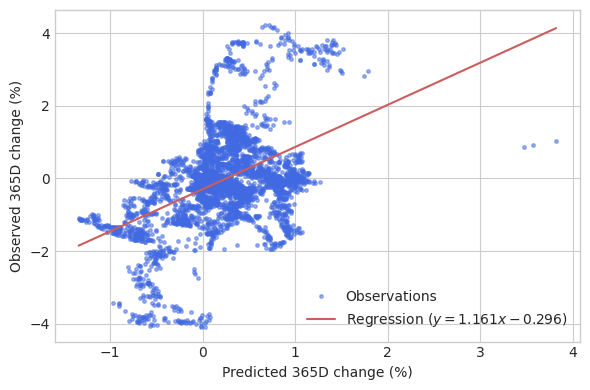

In [24]:
fig = plt.figure(figsize=(6, 4))
nn = np.linspace(min(eurirs_df["D1Y_F2Y1Y"].dropna()), max(eurirs_df["D1Y_F2Y1Y"].dropna()), 100)

plt.plot(eurirs_df["D1Y_F2Y1Y"], eurirs_df["D1Y_1Y"], linestyle="None", marker=".", markersize=5, alpha=0.5, color=data_color, label="Observations")
plt.plot(nn, results.params["Intercept"] + results.params["D1Y_F2Y1Y"] * nn, color=model_color, label=f"Regression ($y = {results.params["D1Y_F2Y1Y"]:.3f} x {'+' if results.params["Intercept"] > 0 else ''} {results.params["Intercept"]:.3f}$)")

plt.legend()
plt.xlabel("Predicted 365D change (%)")
plt.ylabel("Observed 365D change (%)")

fig.tight_layout()
fig.savefig(example_root / "figures" / "EURIRS_regression_1Y_2000_2025.png")
fig.savefig(example_root / "figures" / "EURIRS_regression_1Y_2000_2025.pdf")

plt.show()

#### EURBMK

In [25]:
results = smf.ols("D1Y_1Y ~ D1Y_F2Y1Y", data=eurbmk_df[["D1Y_1Y", "D1Y_F2Y1Y"]].dropna()).fit()

In [26]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 D1Y_1Y   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     437.7
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           3.12e-93
Time:                        18:39:37   Log-Likelihood:                -7171.3
No. Observations:                4994   AIC:                         1.435e+04
Df Residuals:                    4992   BIC:                         1.436e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1574      0.015    -10.544      0.0

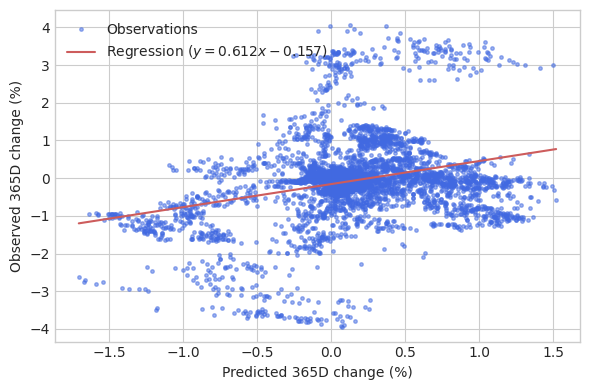

In [27]:
fig = plt.figure(figsize=(6, 4))
nn = np.linspace(min(eurbmk_df["D1Y_F2Y1Y"].dropna()), max(eurbmk_df["D1Y_F2Y1Y"].dropna()), 100)

plt.plot(eurbmk_df["D1Y_F2Y1Y"], eurbmk_df["D1Y_1Y"], linestyle="None", marker=".", markersize=5, alpha=0.5, color=data_color, label="Observations")
plt.plot(nn, results.params["Intercept"] + results.params["D1Y_F2Y1Y"] * nn, color=model_color, label=f"Regression ($y = {results.params["D1Y_F2Y1Y"]:.3f} x {'+' if results.params["Intercept"] > 0 else ''} {results.params["Intercept"]:.3f}$)")

plt.legend()
plt.xlabel("Predicted 365D change (%)")
plt.ylabel("Observed 365D change (%)")

fig.tight_layout()
fig.savefig(example_root / "figures" / "EURBMK_regression_1Y_2000_2025.png")
fig.savefig(example_root / "figures" / "EURBMK_regression_1Y_2000_2025.pdf")

plt.show()